# Algoritmo Genético Simple - Ejemplo Resuelto
**Función objetivo:**
$$f(x, y) = 21.5 + x \cdot \sin(4\pi x) + y \cdot \sin(20\pi y)$$

**Dominio:** $x \in [-3.0,\ 12.1]$, $y \in [4.1,\ 5.8]$

## 1. Importar librerías

In [12]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Parámetros del AGS

In [13]:
Nind   = 100
Lind   = 33
Pc     = 0.9
Pm     = 0.01
Maxgen = 1000
Nvar   = 2
rango  = np.array([[-3, 4.1], [12.1, 5.8]])  # shape (2, Nvar): fila 0 = mínimos, fila 1 = máximos

## 3. Funciones del AGS

In [14]:
def creapob(Nind, Lind):
    """Crea la población inicial aleatoria en binario."""
    return np.random.randint(0, 2, size=(Nind, Lind))

In [15]:
def decodifica(genotipo, rango):
    """Convierte cadenas binarias a valores reales en el dominio del problema."""
    Nvar = rango.shape[1]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)
    fenotipo = np.zeros((Nind, Nvar))
    for i in range(Nind):
        for j in range(Nvar):
            fenotipo[i, j] = np.sum(potencias * genotipo[i, (j*Lvar):(j*Lvar+Lvar)])
    for i in range(Nvar):
        fenotipo[:, i] = rango[0, i] + ((rango[1, i] - rango[0, i]) / (2**Lvar - 1)) * fenotipo[:, i]
    return fenotipo

In [16]:
def objfun(fenotipo):
    """Evalúa la función objetivo para cada individuo."""
    Nind, _ = fenotipo.shape
    objv = np.zeros((Nind, 1))
    for i in range(Nind):
        x, y = fenotipo[i, 0], fenotipo[i, 1]
        objv[i, 0] = 21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)
    return objv

In [17]:
def rankeo(objv, direccion):
    """Asigna aptitud por rankeo lineal (SP=2)."""
    SP = 2
    Nind, _ = objv.shape
    aptitud = np.zeros((Nind, 1))
    sorted_objv = np.sort(objv if direccion == 1 else -objv, axis=0)
    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    posori = np.argsort(sorted_objv, axis=0)
    aptitud[posori, 0] = apt.reshape(-1, 1)
    return aptitud

In [18]:
def ruleta(genotipo, fenotipo, aptitud):
    """Selección proporcional por ruleta."""
    Nind, _ = aptitud.shape
    acumulada = np.cumsum(aptitud / np.sum(aptitud))
    idx = np.zeros(Nind, dtype=int)
    for i in range(Nind):
        aux = np.where(acumulada >= np.random.rand())[0]
        idx[i] = aux[0]
    return genotipo[idx, :]

In [19]:
def xunpunto(nuevo_gen, Pc):
    """Cruza de un punto."""
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy()
    for i in range(0, Nind - 1, 2):
        if np.random.rand() <= Pc:
            corte = np.random.randint(1, Lind)
            aux_gen[i, :]   = np.concatenate((nuevo_gen[i, :corte],   nuevo_gen[i+1, corte:]))
            aux_gen[i+1, :] = np.concatenate((nuevo_gen[i+1, :corte], nuevo_gen[i,   corte:]))
    return aux_gen

In [20]:
def muta(nuevo_gen, Pm):
    """Mutación uniforme bit a bit."""
    mascara = np.random.rand(*nuevo_gen.shape) <= Pm
    return np.logical_xor(nuevo_gen, mascara).astype(int)

## 4. Algoritmo Principal

In [21]:
# Población inicial
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)
objv     = objfun(fenotipo)

Mejor           = np.full((Maxgen, 1), np.nan)
Mejor_cromosoma = np.zeros((Maxgen, Lind))

# Ciclo evolutivo
generaciones = 1
while generaciones < Maxgen:
    aptitud    = rankeo(objv, 1)
    nuevo_gen  = ruleta(genotipo, fenotipo, aptitud)
    nuevo_gen  = xunpunto(nuevo_gen, Pc)
    nuevo_gen  = muta(nuevo_gen, Pm)
    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)
    genotipo, objv = nuevo_gen, nuevo_objv

    idx = np.argmax(objv)
    valor_actual = objv[idx, 0]
    mejor_anterior = np.nanmax(Mejor[:generaciones]) if generaciones > 1 else -np.inf
    Mejor[generaciones] = max(valor_actual, mejor_anterior)
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]
    generaciones += 1

# Resultado final
idx_final  = np.nanargmax(Mejor)
mejor_val  = Mejor[idx_final][0]
mejor_feno = decodifica(Mejor_cromosoma[idx_final].reshape(1, -1), rango)

print(f"Mejor f(x,y) = {mejor_val:.6f}")
print(f"x = {mejor_feno[0,0]:.6f},  y = {mejor_feno[0,1]:.6f}")
print(f"Generación   = {idx_final}")

Mejor f(x,y) = 38.641964
x = 11.623510,  y = 5.621971
Generación   = 645


## 5. Gráficas

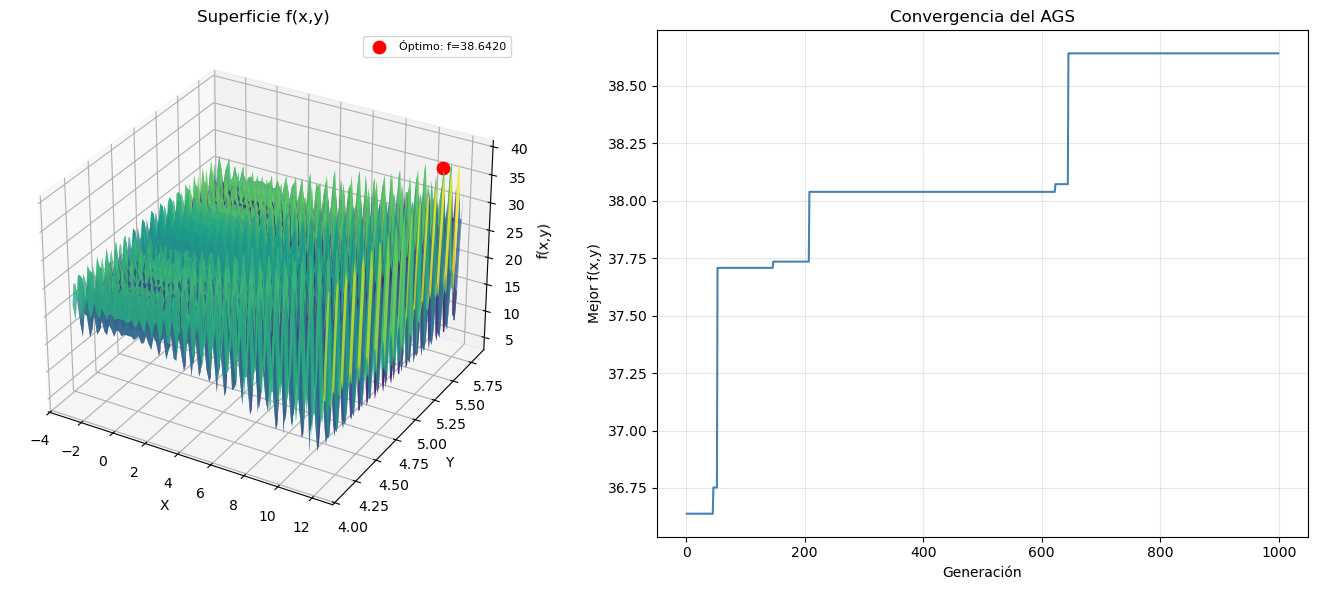

In [22]:
def f(x, y):
    return 21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)

x_v = np.linspace(-3, 12.1, 100)
y_v = np.linspace(4.1, 5.8, 100)
X, Y = np.meshgrid(x_v, y_v)
Z = f(X, Y)

fig = plt.figure(figsize=(14, 6))

# Superficie 3D
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.scatter(mejor_feno[0,0], mejor_feno[0,1], mejor_val,
            color='red', s=80, label=f'Óptimo: f={mejor_val:.4f}')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('f(x,y)')
ax1.set_title('Superficie f(x,y)')
ax1.legend(fontsize=8)

# Convergencia
ax2 = fig.add_subplot(122)
gen_v = np.where(~np.isnan(Mejor[:,0]))[0]
ax2.plot(gen_v, Mejor[gen_v, 0], color='steelblue', linewidth=1.5)
ax2.set_xlabel('Generación'); ax2.set_ylabel('Mejor f(x,y)')
ax2.set_title('Convergencia del AGS')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()